# 🧪LAB: Polynomial Regression as a First Approximation to Non-Linear Problems

In this lab, you will explore **Polynomial Regression** as a simple and intuitive extension of linear models that allows us to handle **non-linear** relationships between predictors and the target variable. While linear regression assumes a straight-line relationship, polynomial regression allows models to capture curves by introducing **non-linear transformations** of the original features. This a great starting point for thinking about **model complexity** and **non-linearity**, and will also be a first approximation to dealing with non-linear problems. Subsequent labs will concentrate on more advance models for this, such as **support vector machine** and **neural networks**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

---
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


NAME(s) = "DJ (Han), Kayla, Mason"

In [ ]:
# NAME(s) = "DJ (Han), Kayla, Mason"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

## 1. Work with synthetic data (35 points)

### a. Generate the data (DJ)
    
- Create a random variable `x` with at least 100 samples drawn from a Gaussian distribution (e.g., mean = 0, standard deviation = 1).

- Define a new variable `y` as a non-linear function of this `x`. You can add noise to make the task more realistic.

(*Hint*: Example of a non-linear function: `y = sin(x) + 0.3 * x² + noise`)

In [ ]:
# (DJ)
np.random.seed(42)

X = np.random.normal(loc = 0, scale = 1, size = 100)

y_true = X ** 2 + np.cos(X)
noise = np.random.normal(loc = 0, scale = 0.3, size = 100)

y_noise = y_true + noise

y = y_noise # y as y_noise

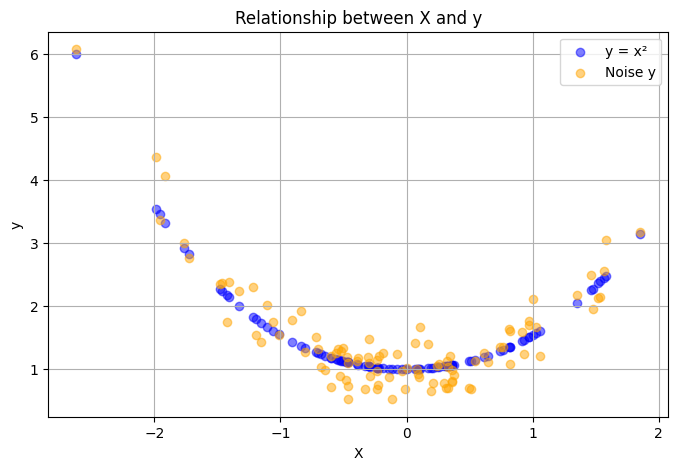

In [ ]:
# (DJ)
plt.figure(figsize=(8, 5))

plt.scatter(X, y_true, color='blue', alpha=0.5, label="y = x²")
plt.scatter(X, y_noise, color='orange', alpha=0.5, label="Noise y")

plt.title("Relationship between X and y")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

- Why do you think it is important to start with a synthetic dataset before using a real one? Elaborate your answer

Creating and starting with a synthetic dataset is important because of bias/variance situations but also situations where one isn't allowed/able to see the dataset.

For the bias/variance section, if we create use both smaller and bigger datasets to train and test the models, we can see how accurately and generally the models predict. From this, we can see if there's more variance vs bias and see the possible overfitting/underfitting.

One might not be able to see the dataset observations. For example, if one were to work with confidential government data, and were working on a data pipeline or model, one would probably create synthetic data to simulate the pipeline or model processes to work later on the actual confidential dataset.

You can also tune the amount of noise to see what the model does. With this, we can see how the model responds in accuracy to more vs less noise. In general, synthetic datasets can replicate complexity and noise, allowing us to isolate the model's functionality before applying it to the messier, real counterparts.

### b. Fit and Visualize Polynomial Regression

- First, fit a linear regression model using `LinearRegression` from `sklearn.linear_model`.
  Plot your predictions over the scatterplot of your original `x` and `y` data. (Kayla)

- Then, apply a polynomial transformation to `x` using `PolynomialFeatures` from `sklearn.preprocessing`.
  Try increasing the **degree** (e.g., 2, 3, 5, 7) and for each case:  (Kayla & DJ)
  - Fit a new model on the transformed features.
  - Plot the predictions on top of the data.
  - Evaluate the model using metrics like MSE, MAE, and R².

**Important**: You should make use of pipelines to combine preprocessing and modeling steps cleanly.

In [ ]:
# train test split with y_noise as y (Kayla)
# imports in first code cell above
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

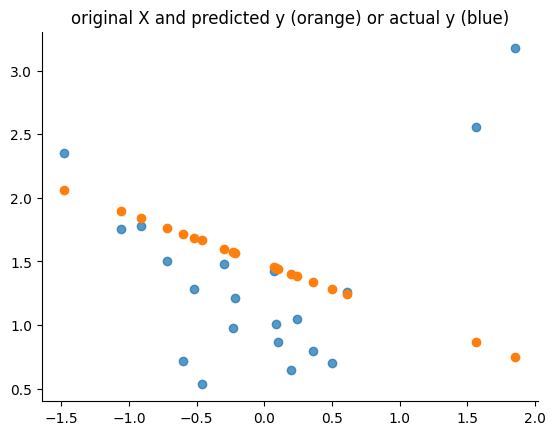

In [ ]:
# fit linear regression model and plot scatter X and y predicted (Kayla)
lin_regress = LinearRegression()
lin_regress.fit(X_train.reshape(-1, 1), y_train)
y_pred = lin_regress.predict(X_test.reshape(-1, 1))

plt.scatter(X_test, y_test, alpha=0.75)
plt.scatter(X_test, y_pred)
plt.title("original X and predicted y (orange) or actual y (blue)")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

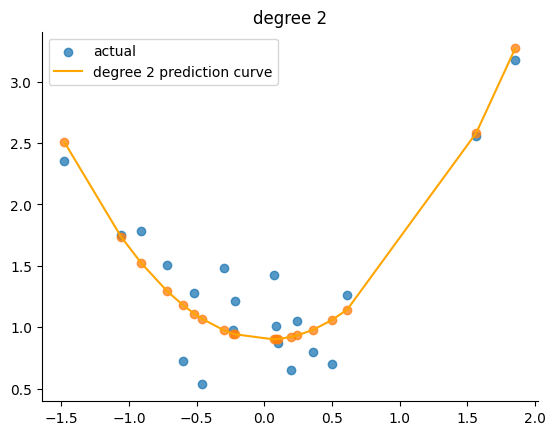


Degree 2: MSE=0.0774, MAE=0.2219, R²=0.8294





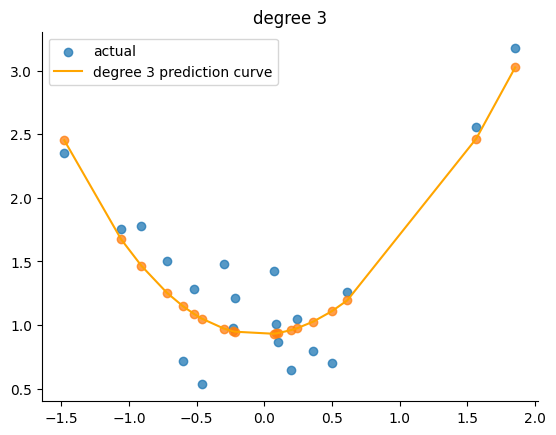


Degree 3: MSE=0.0801, MAE=0.2320, R²=0.8234





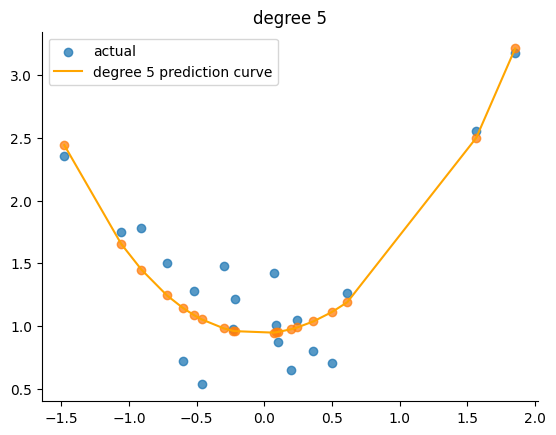


Degree 5: MSE=0.0788, MAE=0.2250, R²=0.8262





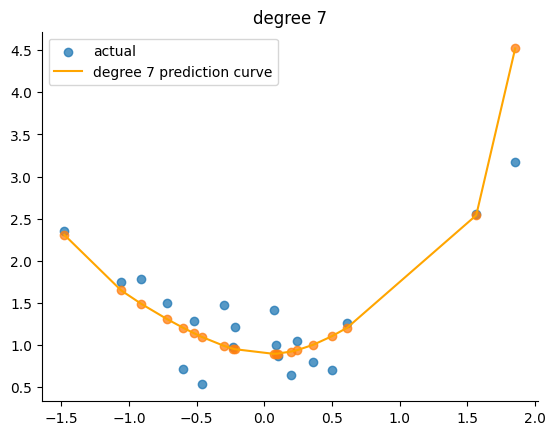


Degree 7: MSE=0.1709, MAE=0.2835, R²=0.6233





In [ ]:
# Pipeline - how we'd do LinearRegression and PolynomialFeatures, degree 2 sample (Kayla & DJ)
linreg = LinearRegression()
X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

pft = PolynomialFeatures(degree=2, include_bias=False)
steps_2 = [("poly", pft), ("linreg", linreg)]
degree2_pipeline = Pipeline(steps_2)
degree2_pipeline.fit(X_train_reshaped, y_train)
y_pred_2 = degree2_pipeline.predict(X_test_reshaped)


# train for each degree of PolynomialFeatures
degrees = [2, 3, 5, 7]

for degree_indiv in degrees:
  pft_new = PolynomialFeatures(degree=degree_indiv, include_bias=False)

  steps_new = [("poly", pft_new), ("linreg", linreg)]
  degree_pipeline_new = Pipeline(steps_new)
  degree_pipeline_new.fit(X_train_reshaped, y_train)

  y_pred_new = degree_pipeline_new.predict(X_test_reshaped)

  order = np.argsort(X_test)
  plt.scatter(X_test, y_test, alpha=0.75, label="actual")
  plt.scatter(X_test, y_pred_new, alpha=0.75)
  plt.plot(X_test[order], y_pred_new[order], label=f"degree {degree_indiv} prediction curve", color='orange')
  plt.title(f"degree {degree_indiv}")
  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)
  plt.legend()
  plt.show()

  # DJ's mse, mae, r2 scores code
  mse = mean_squared_error(y_test, y_pred_new)
  mae = mean_absolute_error(y_test, y_pred_new)
  r2 = r2_score(y_test, y_pred_new)
  print(f"\nDegree {degree_indiv}: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
  print("\n\n")

- **Reflection**: What do you observe about model fit and complexity? Please, elaborate. (Mason)

The data in this example is a function of $x^2$, so we anticipated the polynomial expansion of `degree=2` to model the data most effectively. In the example above, though, each polynomial model of ranging degree value ended up fitting the data similarly. As the complexity (degree value) of the model increased, the fit of the model decreased slightly, though it remained about the same. However, the relationship between model fit and complexity will not always be the same like in this example - it depends on the data.

In this specific dataset and possibly others, it appears higher degrees would lead to overfitting due to the bias-variance tradeoff (bias decreases here but variance increases).

## 2. Application to Real Data

Now, you will apply polynomial regression to a real-world dataset that relates the **compressive strength of high-performance concrete** to various input features such as **cement**, **water**, and **aggregate content**. This dataset originates from a study exploring predictive modeling of concrete strength using neural networks. You instead will start wit hpolynomial regression, a simple approach but that will let you investigate how well it can capture the potentially non-linear relationship between input features and compressive strength.

You can find the dataset here: https://github.com/UVADS/DS-4021/blob/388a5fd8aad496172aafc694163c799b0bd6f5dd/datasets/Concrete_Data.xls, in addition to its metadata: https://github.com/UVADS/DS-4021/blob/388a5fd8aad496172aafc694163c799b0bd6f5dd/datasets/Concrete_Readme.txt.

Reference:

- I-Cheng Yeh, *Modeling of strength of high performance concrete using artificial neural networks*, Cement and Concrete Research, Vol. 28, No. 12, pp. 1797–1808 (1998).

### a. Load the data and create a training and test set. The test set should contain at least 20% of the observations. (DJ)

In [ ]:
! pip install xlrd

In [ ]:
url = "https://raw.githubusercontent.com/UVADS/DS-4021/388a5fd8aad496172aafc694163c799b0bd6f5dd/datasets/Concrete_Data.xls"

dataset = pd.read_excel(url, engine = "xlrd")
print(dataset.head())

   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mixture)  \
0      

In [ ]:
print(dataset.columns)

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')


In [ ]:
#Input Variables (Everything except the last column)
X = dataset.iloc[:, :-1]
#Target Variables (Last column)
y = dataset.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=30)

### b. For each input variable in the dataset, create a **scatterplot** against the outcome variable (`Compressive_Strength`). (DJ)

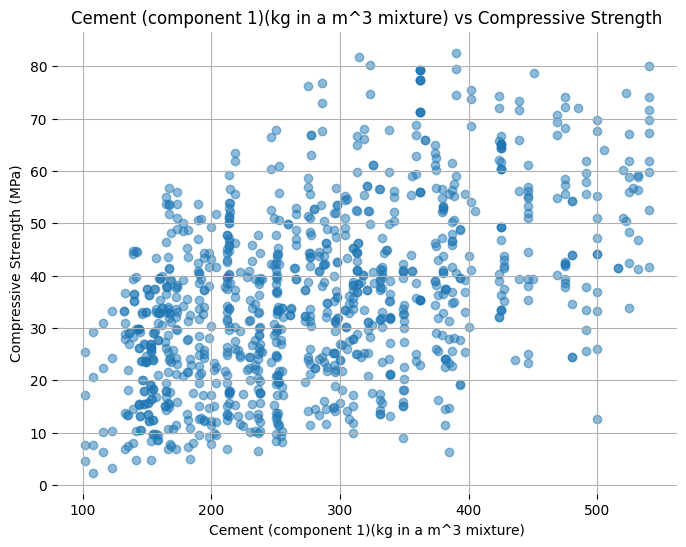

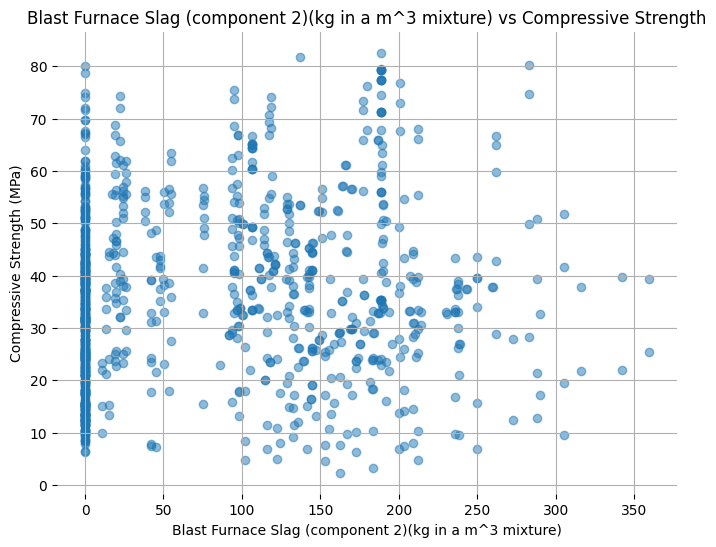

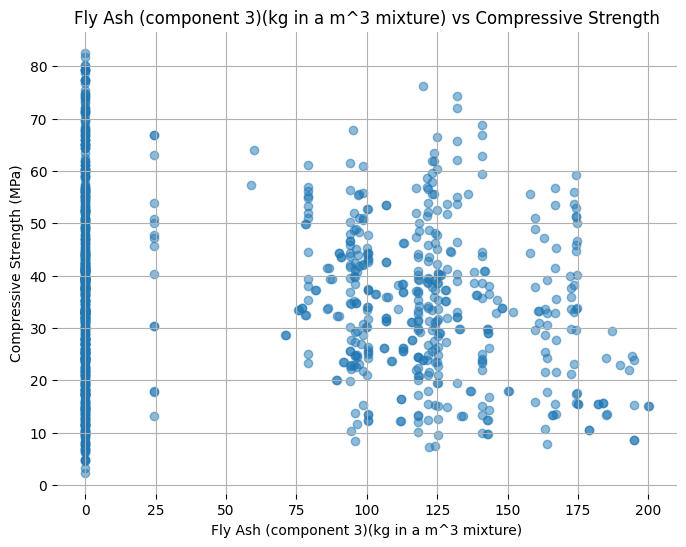

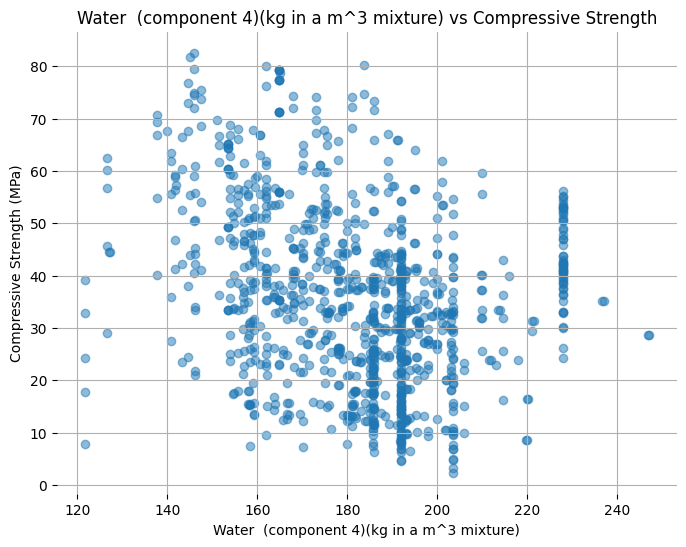

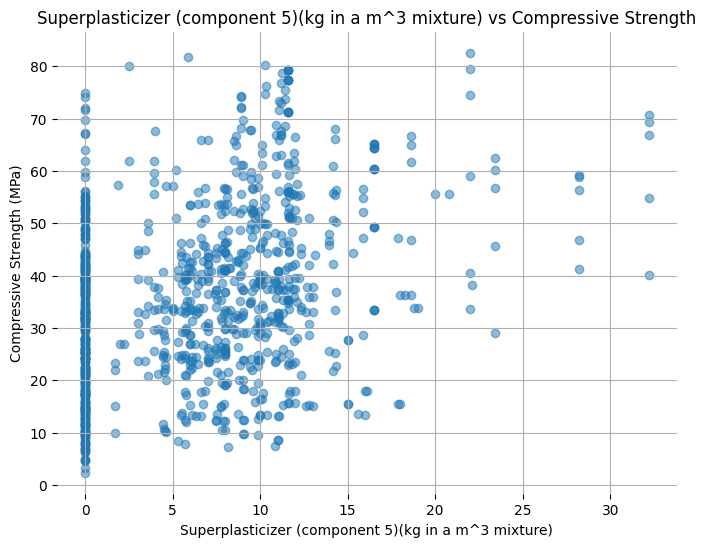

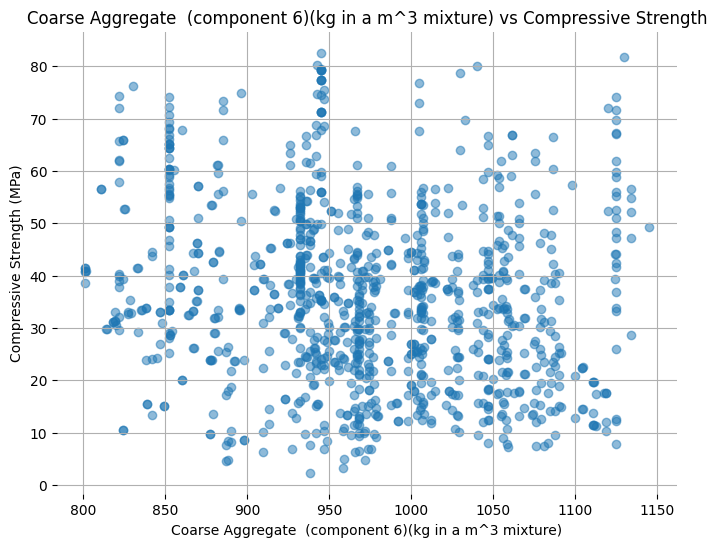

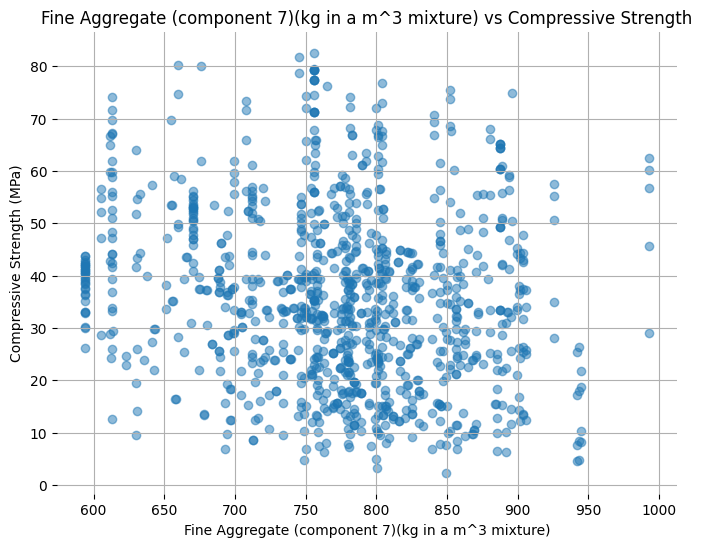

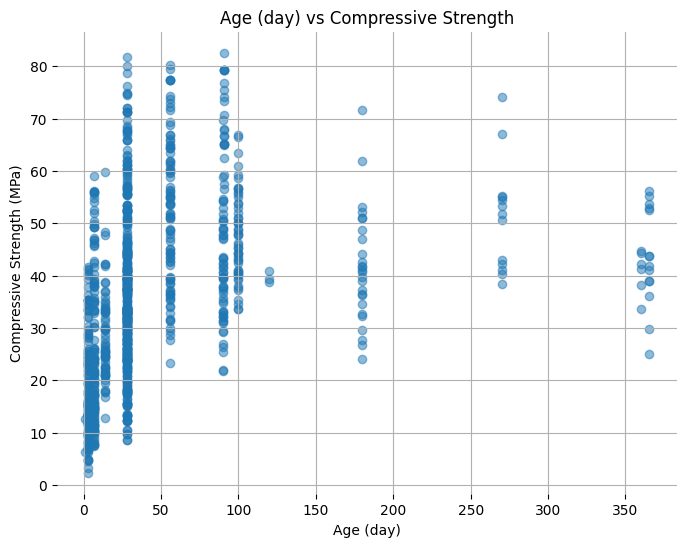

In [ ]:
for col in X.columns:
  plt.figure(figsize = (8,6))
  plt.scatter(X[col], y, alpha = 0.5)
  plt.xlabel(col)
  plt.ylabel("Compressive Strength (MPa)")
  plt.title(f"{col} vs Compressive Strength")
  plt.grid(True)
  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)
  plt.gca().spines['left'].set_visible(False)
  plt.gca().spines['bottom'].set_visible(False)
  plt.show()
  print("\n")

### c. Reflect: Do any variables appear to have a non-linear relationship with the output?  Why might this suggest the need for polynomial regression? Please elaborate on your answers. (DJ)

Cement seems to have a positive relationship with compressive strength, so it looks approximately linear. However, many of the other variables appear to have non-linear relationships with compressive strength, as they are either clustered near zero or show curved, cloud-like patterns rather than a straight line. Since a large majority of the variables appear to have non-linear relationships, using a typical linear regression model may not represent these patterns well enough to make accurate predictions for new points. Polynomial regression allows the model to capture these curved and more complex relationships, potentially improving accuracy in future predictions.

### d. You have probably become convinced that modeling non-linear relationships is necessary in this dataset.  To do this, you’ll be using `PolynomialFeatures` to expand the input features. (DJ)

But before moving on to modelling, you will first inspect how the number of features grows as you increase the degree of the expansion.

- Apply `PolynomialFeatures` to your input variables using degrees 1 through 5.
- For each degree, print the number of resulting features.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
print(X.shape[1]) #Number of original Features - 8

for d in range(1,6):
  poly = PolynomialFeatures(degree = d, include_bias = False)
  #The reason we have to do include_bias = False is becasue include_bias = True is default in scikit learn and will add all column of 1s.
  #Since we know that the number of features is 8, I did include_bias = False.
  X_poly = poly.fit_transform(X)
  print(f"Degree {d}: {X_poly.shape[1]} features")


8
Degree 1: 8 features
Degree 2: 44 features
Degree 3: 164 features
Degree 4: 494 features
Degree 5: 1286 features


### e. Discuss with your group and reflect: (DJ)
    
- How does the number of features grow with increasing degree?
- What implications might this have for model training and interpretability?

Please elaborate on your answers.

The number of features grows combinatorially as the degree increases. This is sometimes described as part of the curse of dimensionality. As the number of features grows, there will be increased computational cost since the training time and memory usage will grow significantly (for example, fitting 1286 features at degree 5). Furthermore, as the number of features increases, the model might overfit because it may start fitting noise in the data as well.

Regarding interpretability, the model's prediction pattern can become more difficult to dissect and understand since many more features can become unintuitive to do so with.

### f. You will fit a LASSO regression model on the expanded features. But before jumping into the implementation, discuss and reflect on the following with your group: (DJ)

- Why are we using LASSO instead of plain linear regression?
- What are the benefits of regularization in this context?
- What preprocessing steps are necessary for LASSO to work properly (e.g., scaling)?

Please elaborate on your answers.

*   The reason we use LASSO instead of plain linear regression is because, as we mentioned in the question above, polynomial expansion creates an excessive number of predictors as the degree increases which can cause overfitting. As we learned in the lecture, LASSO adds an L1 penalty, which not only shrinks coefficients but can set some of them exactly to zero. LASSO, therefore, acts as both regularization and feature selection.

*   Benefits of regularization would be that it would penalize large complexity, and therefore reduce variance and helping to prevent overfitting. Furthermore, since LASSO shrinks irrelevant or weak predictor coefficients to 0, it will leave only the most important features in the model, making it more interpretable.

*   LASSO is sensitive to feature scaling, so we have to scale the features before we proceed to fit the model and use LASSO. We would typically use StandardScaler() to ensure all features are on the same scale before applying LASSO.


---

### g. Now, implement both steps together. That is: (Kayla)

- Apply `PolynomialFeatures` to expand the input features.
- Fit a **Lasso regression model** using two different combinations of:
  - Polynomial `degree`
  - LASSO `alpha` value

Evaluate and compare the models using metrics such as **MSE**, **MAE**, or **R²** on a validation set.

Again, you should make use of pipelines for this.

In [ ]:
# splitting X_test into validation and test sets - half of 0.2 of full dataset (.2 of training set will be validation set:)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=30)

In [ ]:
# (Kayla)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# getting weird output on convergence if don't have max_iter=10000 in Lasso() :(
# import warnings
# from sklearn.exceptions import ConvergenceWarning
# warnings.filterwarnings("ignore", category=ConvergenceWarning)


# fitting first pipeline on degree=2 for pft & alpha=0.1 for lasso
pft_1 = PolynomialFeatures(degree=2, include_bias=False)
ss_1 = StandardScaler()
clf_1 = Lasso(random_state=123, alpha=0.1, max_iter=10000)

steps_1 = [("polynomialFeatures1", pft_1), ("scaler1", ss_1), ("regression1", clf_1)]
pipeline_1 = Pipeline(steps_1)
y_pred_1 = pipeline_1.fit(X_train, y_train).predict(X_val)

mse_1 = mean_squared_error(y_val, y_pred_1)
mae_1 = mean_absolute_error(y_val, y_pred_1)
r2_1 = r2_score(y_val, y_pred_1)



# fitting second pipeline on degree=4 for pft & alpha=0.01 for lasso
pft_2 = PolynomialFeatures(degree=4, include_bias=False)
ss_2 = StandardScaler()
clf_2 = Lasso(random_state=123, alpha=0.01)

steps_2 = [("polynomialFeatures1", pft_2), ("scaler1", ss_2), ("regression1", clf_2)]
pipeline_2 = Pipeline(steps_2)
y_pred_2 = pipeline_2.fit(X_train, y_train).predict(X_val)

mse_2 = mean_squared_error(y_val, y_pred_2)
mae_2 = mean_absolute_error(y_val, y_pred_2)
r2_2 = r2_score(y_val, y_pred_2)



# printing mse, mae, r2 for both pipelines 1 and 2
print(f"MSE, MAE, r2 of pipeline with 2 degrees and 0.1 alpha: {mse_1}, {mae_1}, {r2_1}")
print(f"MSE, MAE, r2 of pipeline with 4 degrees and 0.01 alpha: {mse_2}, {mae_2}, {r2_2}")

MSE, MAE, r2 of pipeline with 2 degrees and 0.1 alpha: 76.95867851595412, 6.92474677804298, 0.7486057455159874
MSE, MAE, r2 of pipeline with 4 degrees and 0.01 alpha: 44.286872543345325, 4.916024655601706, 0.8553319064053999


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.610e+03, tolerance: 1.776e+01
  model = cd_fast.enet_coordinate_descent(


### h. Discuss and reflect with your group: (Kayla)
- How should we go about finding the best combination of degree and alpha?
- What methods could we use to explore this space systematically?
- Is there a data-driven approach for this?

Please elaborate on your answers

It appears that the MSE and MAE scores were less for the higher polynomialfeatures degree (4) and smaller alpha for lasso (0.01). In addition, the r2 score was higher for the same metrics. With these evaluation metrics, one can say that a higher polynomialfeatures degree and smaller alpha for lasso outperforms the smaller degree and larger alpha pipeline, and may become more accurate in prediction as the trends continue. However, the trend may result in overfitting to the training dataset if it continues to extremes. A higher degree and smaller alpha do not always guarantee the minimization of the error.

One could use the gridsearchcv to find the best set of parameters to use in the pipeline's polynomialfeatures and lasso (using cross-validation). One could also plot the learning curve of the model using different parameters to see where underfitting or overfitting occur.

The methods described above use a data-driven approach for this. For example, cross-validation would tune the hyperparameters given the train and validation dataset to minimize the validation errors. In addition, the plot of errors can show us where the validation error is minimal but away from overfitting and underfitting.

### i. Now, expand your model evaluation to include 5 polynomial degrees (1 through 5) and 10 different alpha values for Lasso, spaced logarithmically (e.g., using `np.logspace`)

Now, do the following: (Kayla)

- For each combination of degree and alpha, compute the cross-validated error (e.g., MSE).
- Store the results and generate a plot that summarizes model performance.

In [ ]:
# (Kayla)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pft = PolynomialFeatures(degree=2, include_bias=False)
ss = StandardScaler()
clf = Lasso(random_state=123)

steps = [("polynomialFeatures", pft), ("scaler", ss), ("regression", clf)]
pipeline = Pipeline(steps)

inner_cv = KFold(n_splits = 5, random_state=123, shuffle=True)
param_grid = {"polynomialFeatures__degree": [1, 2, 3, 4, 5], 'regression__alpha': np.logspace(-3, 2, 10)}

grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, n_jobs=1, scoring="neg_mean_squared_error")
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=123, shuffle=True),
             estimator=Pipeline(steps=[('polynomialFeatures',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('regression',
                                        Lasso(random_state=123))]),
             n_jobs=1,
             param_grid={'polynomialFeatures__degree': [1, 2, 3, 4, 5],
                         'regression__alpha': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             scoring='neg_mean_squared_error')

In [ ]:
import pandas as pd

# using cv_results_ from grid.cv optimized model to get mse - stored in 'res'
res = pd.DataFrame(grid.cv_results_)
res["degree"] = res["param_polynomialFeatures__degree"].astype(int)
res["alpha"]  = res["param_regression__alpha"].astype(float)
res["mean_cv_mse"] = -res["mean_test_score"]   # flip sign

# print the 1st rows of degree, alpha, MSE together (uncomment)
# print(res[["degree","alpha","mean_cv_mse"]].head())

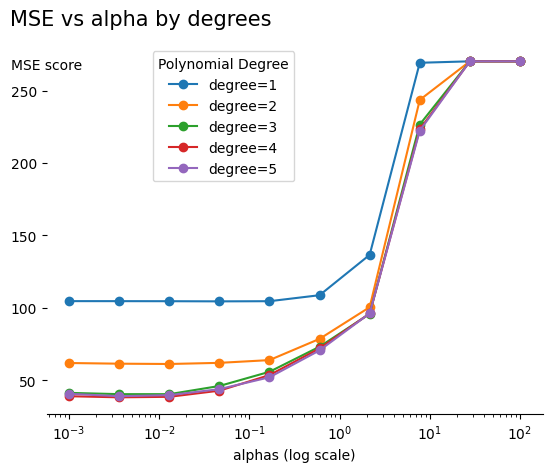

In [ ]:
# plotting by each degree out of our 5 degrees
for d in sorted(res["degree"].unique()):
  subset = res[res["degree"] == d].sort_values("alpha")
  plt.plot(subset["alpha"], subset["mean_cv_mse"], marker="o", label=f"degree={d}")

# cutesy styling (credit DS 2023)
plt.xscale("log")
plt.legend(title="Polynomial Degree", loc="upper left", bbox_to_anchor=(0.2, 1))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.title("MSE vs alpha by degrees", y=1.03, x=0.19, size=15)
plt.xlabel("alphas (log scale)")
plt.text(0.00023, 265, "MSE score")
plt.show()

### j. Discuss and reflect with your group: (Mason)

- Why did you choose this type of plot to summarize results?
- Can you think of a better or more informative visualization?

Please elaborate on your answers

The plot above was chosen in order to show the degree and alpha for lasso, displaying their corresponding MSE scores. With the alpha values on the x-axis and the MSE on the y-axis, the trends could be further separated by degree of polynomial features. This graph uses log x scaling in order to horizontally condense the results, considering that the alphas were generated on a log scale as well.

Another way to visualize these results would be to create a heatmap with degree value and alpha on the axes. Each cell would represent a model with the corresponding alpha value and number of degrees. The temperature (or shade) of each cell could be based on either the $R^2$ score or MSE for that model with the designated parameters.

### k. Using the most optimal model (based on your previous cross-validation results), generate predictions on the test set. In addition, create a plot comparing the predicted values against the observed values. (Mason)

In [ ]:
# Find the most optimal model
best_model = grid.best_estimator_
best_params = grid.best_params_
best_mse = grid.best_score_

# Print the parameters of the best model.
print("Best Model:")
print(f"Number of Degrees = {best_params['polynomialFeatures__degree']}")
print(f"Alpha Value = {best_params['regression__alpha'].round(6)}")
print(f"MSE Score = {abs(best_mse.round(2))}")


Best Model:
Number of Degrees = 4
Alpha Value = 0.003594
MSE Score = 38.17


In [ ]:
# Use the best model to predict on the test set
y_pred = best_model.predict(X_test)

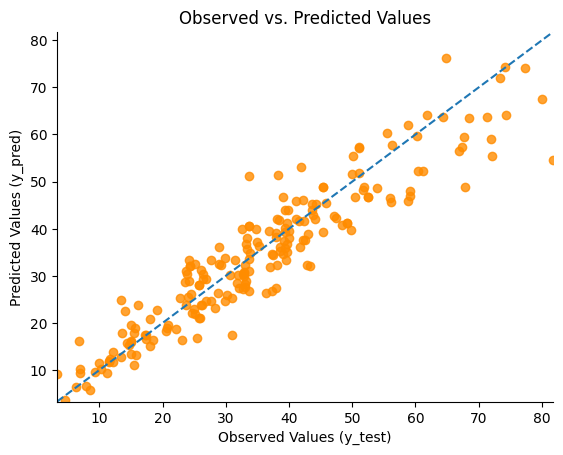

In [ ]:
# Compare the predicted values with the observed values
plt.scatter(y_test, y_pred, c="DarkOrange", alpha=0.8)
plt.xlabel("Observed Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Observed vs. Predicted Values")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

### L. Identify the most important features from the LASSO model. (Mason)

---



In [ ]:
# Determine the most important features from the Lasso step in the best model
coefs = best_model.named_steps['regression'].coef_
feature_names = best_model.named_steps['polynomialFeatures'].get_feature_names_out(X_train.columns)

# Make a dataframe for the most important features
feature_importance = pd.DataFrame({"Feature": feature_names, "Coefficient": abs(coefs)})

# Make a dataframe with the ten most important features
feature_importance_top10 = feature_importance.sort_values("Coefficient", ascending=False).head(10)

# Print table of most important features
print(feature_importance_top10)

# Print the number of features set to zero by Lasso Regularization
print("\nNumber of features set to 0:", (feature_importance['Coefficient'] == 0).sum())

                                               Feature  Coefficient
0            Cement (component 1)(kg in a m^3 mixture)    24.324507
478  Superplasticizer (component 5)(kg in a m^3 mix...    20.339245
3            Water  (component 4)(kg in a m^3 mixture)    11.108824
492  Fine Aggregate (component 7)(kg in a m^3 mixtu...    10.228654
488  Coarse Aggregate  (component 6)(kg in a m^3 mi...    10.201069
153  Superplasticizer (component 5)(kg in a m^3 mix...     9.816380
2           Fly Ash (component 3)(kg in a m^3 mixture)     8.853998
493                                        Age (day)^4     8.551196
426  Water  (component 4)(kg in a m^3 mixture)^3 Co...     8.496421
164        Cement (component 1)(kg in a m^3 mixture)^4     8.477946

Number of features set to 0: 195


In [ ]:
print(len(feature_names))

494


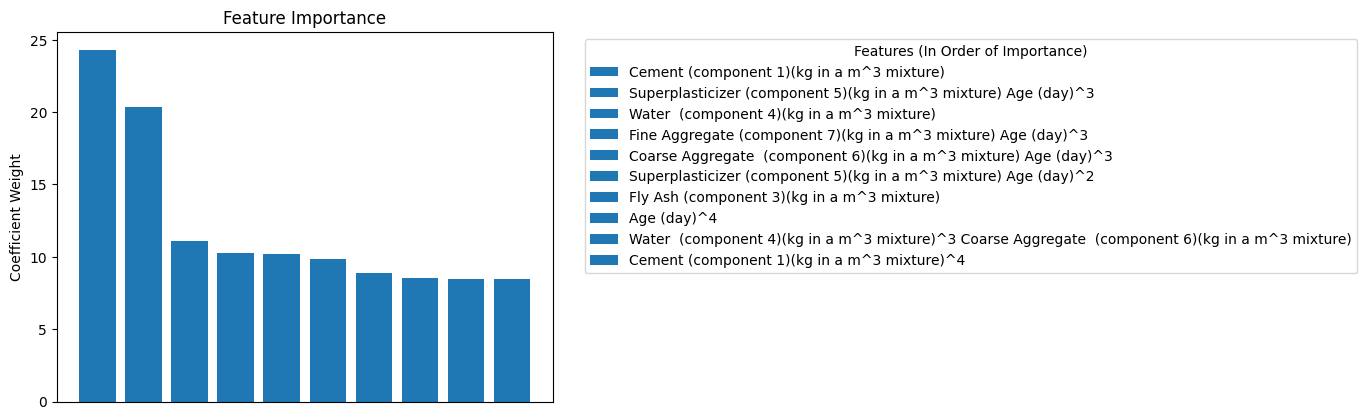

In [ ]:
# Plot the most important features
barplot = plt.bar(feature_importance_top10['Feature'], feature_importance_top10['Coefficient'])
plt.title("Feature Importance")
plt.ylabel("Coefficient Weight")
plt.xticks([])
plt.legend(barplot, feature_importance_top10["Feature"], title='Features (In Order of Importance)', bbox_to_anchor=(1.05, 1))
plt.show()

Reflect: (Mason)
- Do the important features make intuitive sense?
- Are any of them polynomial interaction terms? What might that tell you?

Please, elaborate on your answers.

Based on the variable importances found above, **cement**, **wate**r, and **age** seem to be the most important predictors - they each appear in the top ten features dataframe multiple times. Cement and water are the two ingredients for making concrete, so it is intuitive to me that they have a notable impact on compressive strength. Additionally, it makes sense to assume that the age of the concrete affects its strength and material properties.

The majority of the top ten important features are polynomial interaction terms. These features indicate that the relationships between these features and the target variable are non-linear and are able to be captured by a polynomial term.

After expanding the degree, there were 494 features, 299 of which were NOT set to 0. Lasso drastically reduced the total features by the L1 penalty to "select" features that more contributed to the predictions.

## 3. Collaboration Reflection (5 points)

As a group, briefly reflect on the following (max 1–2 short paragraphs):

- How did the group dynamics work throughout the assignment?
- Were there any major disagreements or diverging approaches?
- How did you resolve conflicts or make final modeling decisions?
- What did you learn from each other during this project?

Our group dynamics felt the same as last lab 1. We worked well and efficiently asynchronously and only met during the last Wednesday class. We had a slight divergence on whether or not we should use pipelines for the first part. We ended up using pipelines per the directions after DJ acknowledged and respected that the code was simpler with. We then used DJ's scores code for MSE, MAE, and $R^2$.

We learned from each other that DJ is very free on Wednesday nights (and every nights) to start the assignment earliest. We also have more trust in each other to finish our assigned parts early on. We are non-procrastinators and enjoy working together. Therefore, doing the assignment when it releases at Wednesday classes is best for us all.